# Analise descritiva de estabelecimentos

Este notebook le o arquivo de estabelecimentos (priorizando a pasta `dados/`) e gera analises descritivas basicas das variaveis disponiveis.

In [1]:
from pathlib import Path
import pandas as pd

# Busca o arquivo de estabelecimentos na pasta dados; se nao houver, tenta a raiz do projeto
possible_files = sorted((Path('..') / 'dados').glob('estabelecimentos*.csv'))
if not possible_files:
    possible_files = sorted(Path('..').glob('estabelecimentos*.csv'))

if not possible_files:
    raise FileNotFoundError(
        'Nenhum arquivo de estabelecimentos encontrado em ../dados/ ou na raiz do projeto.'
    )

file_path = possible_files[0]
print(f'Arquivo selecionado: {file_path}')

df = pd.read_csv(file_path)
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head()

Arquivo selecionado: ../dados/estabelecimentos_processado.csv
Linhas: 152777 | Colunas: 25


,id_est,cnpj_completo,id_emp,nome_fantasia,situacao_cadastral,data_situacao_cadastral,data_inicio_atividade,duracao_atividade,cnae_fiscal_principal,enderecos,...,uf,telefone1,telefone2,correio_eletronico,google_latitude,google_longitude,id_frq,nome_franquia,id_kognita,shopping_nome
0,est_00003702,841775000270,emp_0000996,NaN,Baixada,2003-11-11,1996-06-11,7.421918,4619200,"Quadra C 9 Lote 09, S/N - Taguatinga Norte, Br...",...,DF,NaN,NaN,NaN,-15.833294,-48.057778,NaN,NaN,NaN,NaN
1,est_00010491,2012862010637,emp_0002741,NaN,Baixada,2009-09-10,2007-02-07,2.591781,5111100,"Rua Joao Azevedo Marques, 211 - Jardim Tres Ma...",...,SP,(11) 5582-6117,(11) 5582-8226,carlos.souza@tam.com.br,-23.684433,-46.557698,NaN,NaN,NaN,NaN
2,est_00152006,35350503000171,emp_0068704,Chuvatec,Inapta,2019-01-31,1990-06-05,28.676712,4789099,"Avenida Ulisses De Guimaraes, 409 - Portal Da ...",...,PE,NaN,NaN,NaN,-9.376310,-40.537334,NaN,NaN,NaN,NaN
3,est_00051882,8668165000490,emp_0018373,Capim Limao,Baixada,2012-09-19,2010-10-15,1.931507,4755503,"Rua Professor Pedro Viriato Parigot De Souza, ...",...,PR,(41) 3335-9506,(41) 3335-8315,sgacontas@brturbo.com.br,-25.435969,-49.317957,NaN,NaN,302.0,ParkShopping Barigui
4,est_00235001,60701190403055,emp_0121287,NaN,Baixada,2012-06-18,2009-04-07,3.200000,6422100,"Rua Boa Vista, 150 - Centro, São Paulo - SP, 0...",...,SP,(11) 5019-8135,NaN,NaN,-23.546399,-46.633159,NaN,NaN,NaN,NaN


In [2]:
# Informacoes gerais e tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 152777 entries, 0 to 152776
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_est                   152777 non-null  str    
 1   cnpj_completo            152777 non-null  int64  
 2   id_emp                   152777 non-null  str    
 3   nome_fantasia            91358 non-null   str    
 4   situacao_cadastral       152777 non-null  str    
 5   data_situacao_cadastral  152049 non-null  str    
 6   data_inicio_atividade    152777 non-null  str    
 7   duracao_atividade        51193 non-null   float64
 8   cnae_fiscal_principal    152777 non-null  int64  
 9   enderecos                152702 non-null  str    
 10  numero                   152775 non-null  str    
 11  complemento              102266 non-null  str    
 12  bairro                   152435 non-null  str    
 13  cep                      152777 non-null  str    
 14  municipio_nome 

In [3]:
# Estatisticas descritivas para variaveis numericas
desc_num = df.describe(include=['number']).T
desc_num

,count,mean,std,min,25%,50%,75%,max
cnpj_completo,152777.0,3.084981e+13,2.170577e+13,1.720002e+08,1.102317e+13,2.827494e+13,4.862058e+13,9.810292e+13
duracao_atividade,51193.0,7.519493e+00,7.373628e+00,-1.863014e+00,2.320548e+00,5.123288e+00,1.044384e+01,6.010137e+01
cnae_fiscal_principal,152777.0,5.687009e+06,1.723244e+06,1.113010e+05,4.755503e+06,5.223100e+06,6.462000e+06,9.700500e+06
google_latitude,152635.0,-1.929980e+01,7.123163e+00,-3.369268e+01,-2.355809e+01,-2.272572e+01,-1.580359e+01,4.885755e+01
google_longitude,152635.0,-4.617258e+01,5.228205e+00,-7.277342e+01,-4.897381e+01,-4.667053e+01,-4.326972e+01,1.125767e+01
id_kognita,25892.0,3.231795e+02,1.868555e+02,1.000000e+00,1.780000e+02,3.090000e+02,4.500000e+02,9.190000e+02


In [4]:
# Estatisticas descritivas para variaveis categoricas
desc_cat = df.describe(include=['object', 'category', 'bool']).T
desc_cat

/tmp/ipykernel_2749312/4152279799.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  desc_cat = df.describe(include=['object', 'category', 'bool']).T


,count,unique,top,freq
id_est,152777,152777,est_00003702,1
id_emp,152777,83599,emp_0121287,5101
nome_fantasia,91358,40537,O Boticario,2941
situacao_cadastral,152777,5,Ativa,101584
data_situacao_cadastral,152049,8087,2005-11-03,6627
data_inicio_atividade,152777,11983,1973-06-28,374
enderecos,152702,99577,"Rua Desembargador Ferreira Coelho, 335 - Praia...",511
numero,152775,10083,S/N,9113
complemento,102266,61731,Sala 01,1319
bairro,152435,13575,Centro,33654


In [5]:
# Percentual de valores ausentes por coluna
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).rename('pct_ausentes')
missing_pct.to_frame().head(20)

,pct_ausentes
shopping_nome,83.052423
id_kognita,83.052423
telefone2,74.173469
duracao_atividade,66.491684
nome_franquia,66.031536
id_frq,66.031536
nome_fantasia,40.201732
complemento,33.061914
correio_eletronico,21.905784
telefone1,8.636117


In [6]:
# Cardinalidade das colunas categoricas (top 20)
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
cardinalidade = df[cat_cols].nunique(dropna=False).sort_values(ascending=False).head(20)
cardinalidade

/tmp/ipykernel_2749312/466616642.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


id_est                     152777
enderecos                   99578
id_emp                      83599
complemento                 61732
telefone1                   56707
correio_eletronico          50622
cep                         43869
nome_fantasia               40538
telefone2                   19741
bairro                      13576
data_inicio_atividade       11983
numero                      10084
data_situacao_cadastral      8088
municipio_nome               3573
nome_franquia                1490
id_frq                       1490
shopping_nome                 703
uf                             28
situacao_cadastral              5
dtype: int64

## Analise descritiva da situacao cadastral

Resumo da distribuicao de situacao cadastral com contagens e percentuais, seguido de uma visao temporal por ano da data da situacao cadastral.

In [3]:
col_sit = 'situacao_cadastral'
col_data = 'data_situacao_cadastral'

if col_sit not in df.columns:
    raise KeyError(f"Coluna '{col_sit}' nao encontrada no arquivo.")

# Padroniza nulos e espacos para evitar categorias vazias na analise.
sit_serie = (
    df[col_sit]
    .fillna('Nao informado')
    .astype(str)
    .str.strip()
    .replace('', 'Nao informado')
)

situacao_resumo = (
    sit_serie
    .value_counts(dropna=False)
    .rename_axis('situacao_cadastral')
    .reset_index(name='qtd')
)
situacao_resumo['pct'] = (situacao_resumo['qtd'] / len(df) * 100).round(2)

print('=' * 80)
print('DISTRIBUICAO DA SITUACAO CADASTRAL')
print('=' * 80)
display(situacao_resumo)

print(f"\nTotal de registros: {len(df):,}".replace(',', '.'))
print(
    f"Categoria predominante: {situacao_resumo.loc[0, 'situacao_cadastral']} "
    f"({situacao_resumo.loc[0, 'pct']:.2f}%)"
)

if col_data in df.columns:
    datas = pd.to_datetime(df[col_data], errors='coerce')
    base_temporal = pd.DataFrame({
        'ano': datas.dt.year,
        'situacao_cadastral': sit_serie,
    }).dropna(subset=['ano'])
    base_temporal['ano'] = base_temporal['ano'].astype(int)

    dist_ano = (
        base_temporal
        .groupby(['ano', 'situacao_cadastral'])
        .size()
        .reset_index(name='qtd')
        .sort_values(['ano', 'qtd'], ascending=[True, False])
    )
    dist_ano['pct_no_ano'] = (
        dist_ano['qtd']
        / dist_ano.groupby('ano')['qtd'].transform('sum')
        * 100
    ).round(2)

    ultimos_anos = sorted(dist_ano['ano'].unique())[-10:]
    dist_ano_recente = dist_ano[dist_ano['ano'].isin(ultimos_anos)]

    print('\nTop 3 situacoes cadastrais por ano (ultimos 10 anos com dados):')
    display(dist_ano_recente.groupby('ano').head(3).reset_index(drop=True))
else:
    print(f"\nColuna '{col_data}' nao encontrada; analise temporal nao gerada.")

DISTRIBUICAO DA SITUACAO CADASTRAL


,situacao_cadastral,qtd,pct
0,Ativa,101584,66.49
1,Baixada,46919,30.71
2,Inapta,3604,2.36
3,Suspensa,620,0.41
4,Nula,50,0.03



Total de registros: 152.777
Categoria predominante: Ativa (66.49%)

Top 3 situacoes cadastrais por ano (ultimos 10 anos com dados):


,ano,situacao_cadastral,qtd,pct_no_ano
0,2016,Ativa,3103,59.38
1,2016,Baixada,2110,40.38
2,2016,Suspensa,12,0.23
3,2017,Ativa,3779,62.26
4,2017,Baixada,2275,37.48
5,2017,Inapta,11,0.18
6,2018,Ativa,4635,57.70
7,2018,Baixada,2243,27.92
8,2018,Inapta,1145,14.25
9,2019,Ativa,5774,63.19


### Visualizacoes

Graficos para facilitar a leitura da distribuicao atual e da evolucao temporal da situacao cadastral.

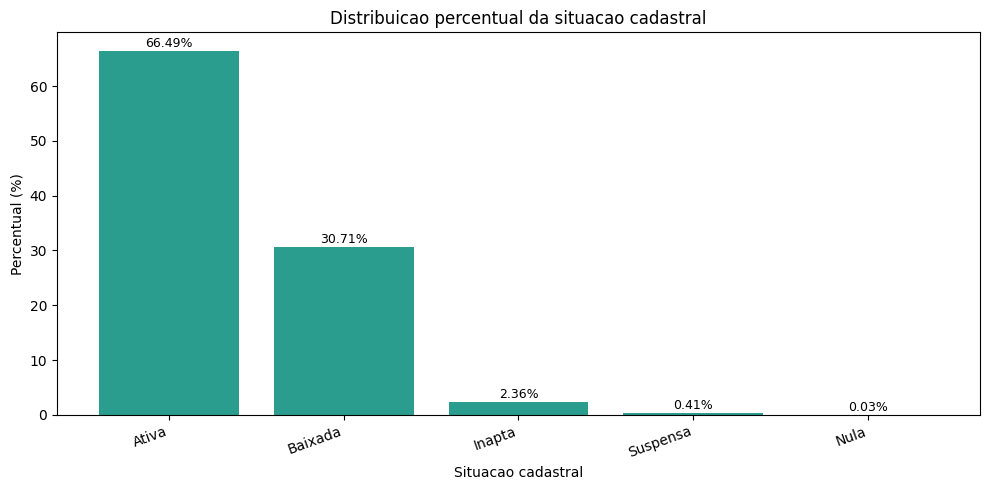

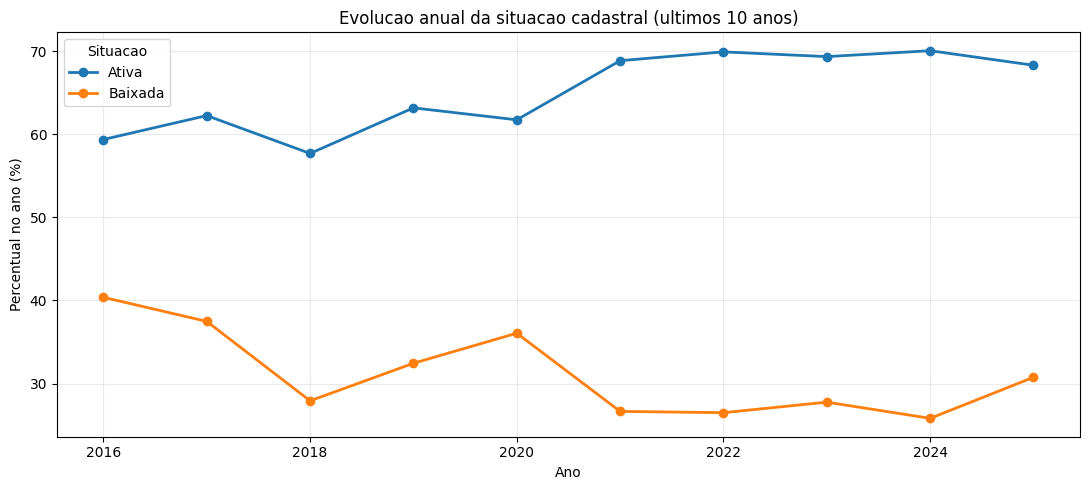

In [4]:
import matplotlib.pyplot as plt

# Grafico 1: distribuicao percentual da situacao cadastral no total da base.
plt.figure(figsize=(10, 5))
plt.bar(situacao_resumo['situacao_cadastral'], situacao_resumo['pct'], color='#2a9d8f')
plt.title('Distribuicao percentual da situacao cadastral')
plt.xlabel('Situacao cadastral')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(situacao_resumo['pct']):
    plt.text(i, v + 0.15, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Grafico 2: evolucao dos percentuais anuais de Ativa e Baixada nos ultimos 10 anos.
if 'dist_ano_recente' in globals() and not dist_ano_recente.empty:
    principais = ['Ativa', 'Baixada']
    serie_principais = (
        dist_ano_recente[dist_ano_recente['situacao_cadastral'].isin(principais)]
        .pivot(index='ano', columns='situacao_cadastral', values='pct_no_ano')
        .fillna(0)
        .sort_index()
    )

    plt.figure(figsize=(11, 5))
    for col in serie_principais.columns:
        plt.plot(serie_principais.index, serie_principais[col], marker='o', linewidth=2, label=col)

    plt.title('Evolucao anual da situacao cadastral (ultimos 10 anos)')
    plt.xlabel('Ano')
    plt.ylabel('Percentual no ano (%)')
    plt.grid(alpha=0.25)
    plt.legend(title='Situacao')
    plt.tight_layout()
    plt.show()
else:
    print('Nao ha base temporal disponivel para gerar o grafico de evolucao anual.')

## Validação de Telefones

Regras de validação (padrão brasileiro):
- **Telefone válido**: após remover não-dígitos e código de país (55), deve ter 10 ou 11 dígitos com DDD entre 11 e 99
- **Celular**: telefone válido com 11 dígitos onde o dígito após o DDD é 9

In [2]:
def limpar_telefone(serie):
    """Remove não-dígitos, zeros à esquerda (prefixo interurbano) e código de país 55."""
    digitos = serie.fillna('').astype(str).str.replace(r'\D', '', regex=True)
    # Remove zeros à esquerda (prefixo 0 / 00 de discagem interurbana)
    digitos = digitos.str.lstrip('0')
    # Remove código de país 55 se o número ficou com 12 ou 13 dígitos
    digitos = digitos.where(
        ~((digitos.str.len().isin([12, 13])) & (digitos.str[:2] == '55')),
        digitos.str[2:]
    )
    return digitos


def validar_telefone(digitos):
    """Valida telefone brasileiro: 10-11 dígitos, DDD entre 11 e 99."""
    tamanho_ok = digitos.str.len().isin([10, 11])
    ddd = pd.to_numeric(digitos.str[:2], errors='coerce')
    ddd_ok = ddd.between(11, 99)
    tem_valor = digitos.str.len() > 0
    return tem_valor & tamanho_ok & ddd_ok


def classificar_celular(digitos, valido):
    """
    Identifica celular (somente se válido):
    - 11 dígitos: DDD + 9 + 8 dígitos (formato atual com nono dígito)
    - 10 dígitos: DDD + 9XXX-XXXX (formato antigo sem nono dígito)
    """
    digito_apos_ddd = digitos.str[2]
    eh_11_com_9 = (digitos.str.len() == 11) & (digito_apos_ddd == '9')
    eh_10_com_9 = (digitos.str.len() == 10) & (digito_apos_ddd == '9')
    return valido & (eh_11_com_9 | eh_10_com_9)


# Limpar telefones
tel1_digitos = limpar_telefone(df['telefone1'])
tel2_digitos = limpar_telefone(df['telefone2'])

# Validar telefones
df['telefone1_valido'] = validar_telefone(tel1_digitos)
df['telefone2_valido'] = validar_telefone(tel2_digitos)

# Classificar celular (somente quando válido)
df['telefone1_celular'] = classificar_celular(tel1_digitos, df['telefone1_valido'])
df['telefone2_celular'] = classificar_celular(tel2_digitos, df['telefone2_valido'])

# Diagnóstico rápido
for col in ['telefone1', 'telefone2']:
    total = df[col].notna().sum()
    validos = df[f'{col}_valido'].sum()
    celulares = df[f'{col}_celular'].sum()
    fixos = validos - celulares
    print(f"{col}: {total} preenchidos | {validos} válidos ({validos/total*100:.1f}%) | "
          f"{celulares} celulares | {fixos} fixos")

telefone1: 139583 preenchidos | 136873 válidos (98.1%) | 23501 celulares | 113372 fixos
telefone2: 39457 preenchidos | 31551 válidos (80.0%) | 7094 celulares | 24457 fixos


In [21]:
# Resumo comparativo das validações
validacao_resumo = pd.DataFrame({
    'Telefone': ['telefone1', 'telefone2'],
    'Preenchidos': [df['telefone1'].notna().sum(), df['telefone2'].notna().sum()],
    'Validos': [df['telefone1_valido'].sum(), df['telefone2_valido'].sum()],
    'Invalidos': [
        df['telefone1'].notna().sum() - df['telefone1_valido'].sum(),
        df['telefone2'].notna().sum() - df['telefone2_valido'].sum()
    ],
    'Celulares': [df['telefone1_celular'].sum(), df['telefone2_celular'].sum()],
    'Fixos': [
        (df['telefone1_valido'] & ~df['telefone1_celular']).sum(),
        (df['telefone2_valido'] & ~df['telefone2_celular']).sum()
    ],
})
validacao_resumo['Pct_Validos'] = (validacao_resumo['Validos'] / validacao_resumo['Preenchidos'] * 100).round(2)
validacao_resumo['Pct_Celulares'] = (validacao_resumo['Celulares'] / validacao_resumo['Validos'] * 100).round(2)

print("=" * 80)
print("RESUMO DA VALIDAÇÃO DE TELEFONES")
print("=" * 80)
validacao_resumo

RESUMO DA VALIDAÇÃO DE TELEFONES


,Telefone,Preenchidos,Validos,Invalidos,Celulares,Fixos,Pct_Validos,Pct_Celulares
0,telefone1,139583,136873,2710,23501,113372,98.06,17.17
1,telefone2,39457,31551,7906,7094,24457,79.96,22.48


### Top numeros registrados (Top 10 + Outros)

Ranking dos numeros mais frequentes em telefone1 e telefone2 apos limpeza dos digitos.

In [6]:
def top_numeros_com_outros(serie_digitos, top_n=10):
    serie_limpa = serie_digitos[serie_digitos.str.len() > 0]
    freq = serie_limpa.value_counts()

    if freq.empty:
        return pd.DataFrame(columns=['numero', 'qtd', 'pct'])

    top = freq.head(top_n).rename_axis('numero').reset_index(name='qtd')
    outros_qtd = int(freq.iloc[top_n:].sum())

    if outros_qtd > 0:
        top = pd.concat(
            [top, pd.DataFrame([{'numero': 'Outros', 'qtd': outros_qtd}])],
            ignore_index=True,
        )

    top['pct'] = (top['qtd'] / freq.sum() * 100).round(2)
    return top


for nome_col, serie_digitos in [('telefone1', tel1_digitos), ('telefone2', tel2_digitos)]:
    ranking = top_numeros_com_outros(serie_digitos, top_n=10)

    print('=' * 80)
    print(f'TOP NUMEROS - {nome_col.upper()} (TOP 10 + OUTROS)')
    print('=' * 80)

    if ranking.empty:
        print('Sem numeros preenchidos apos limpeza.')
    else:
        display(ranking)

TOP NUMEROS - TELEFONE1 (TOP 10 + OUTROS)


,numero,qtd,pct
0,3132479460,1176,0.84
1,1141969800,1142,0.82
2,1130034828,1101,0.79
3,2125036850,1029,0.74
4,2730244150,1013,0.73
5,1123970320,986,0.71
6,1133650800,931,0.67
7,1155822192,751,0.54
8,3123237160,732,0.52
9,1121618000,731,0.52


TOP NUMEROS - TELEFONE2 (TOP 10 + OUTROS)


,numero,qtd,pct
0,8008881955,439,1.37
1,8009792020,246,0.77
2,1121618000,165,0.52
3,3132477760,162,0.51
4,5433167546,160,0.50
5,40001515,153,0.48
6,1137557000,114,0.36
7,3132477762,105,0.33
8,2172128260,84,0.26
9,1136464301,81,0.25


In [18]:
# Amostras de telefones inválidos para diagnóstico
tel1_digitos = limpar_telefone(df['telefone1'])
invalidos_mask = df['telefone1'].notna() & ~df['telefone1_valido']
amostra_invalidos = df.loc[invalidos_mask, 'telefone1'].head(10)

print("Exemplos de telefone1 inválidos (até 10):")
for idx, val in amostra_invalidos.items():
    digitos = tel1_digitos.loc[idx]
    print(f"  Original: {val!r:30s} | Dígitos: {digitos!r:15s} (len={len(digitos)})")

Exemplos de telefone1 inválidos (até 10):
  Original: '(038) 2225-500'               | Dígitos: '382225500'     (len=9)
  Original: '(92) 3648-800'                | Dígitos: '923648800'     (len=9)
  Original: '(77) 4246-370'                | Dígitos: '774246370'     (len=9)
  Original: '(021) 5448-524'               | Dígitos: '215448524'     (len=9)
  Original: '(48) 2221-855'                | Dígitos: '482221855'     (len=9)
  Original: '(021) 2201-414'               | Dígitos: '212201414'     (len=9)
  Original: '(71) 3751-431'                | Dígitos: '713751431'     (len=9)
  Original: '(51) 6351-365'                | Dígitos: '516351365'     (len=9)
  Original: '(011) 2551-155'               | Dígitos: '112551155'     (len=9)
  Original: '(61) 3218-854'                | Dígitos: '613218854'     (len=9)


In [19]:
# Diagnóstico detalhado: distribuição de comprimento e primeiro dígito após DDD no telefone1
t1 = tel1_digitos[df['telefone1'].notna() & (tel1_digitos.str.len() > 0)]

print("=== Distribuição de comprimento (telefone1 limpo) ===")
print(t1.str.len().value_counts().sort_index())

print("\n=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 10 dígitos ===")
mask_10 = t1.str.len() == 10
print(t1[mask_10].str[2].value_counts().sort_index())

print(f"\nQuantos com 10 dígitos começam com 9 após DDD: {(t1[mask_10].str[2] == '9').sum()}")

print("\n=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 11 dígitos ===")
mask_11 = t1.str.len() == 11
print(t1[mask_11].str[2].value_counts().sort_index())

print(f"\nQuantos com 11 dígitos começam com 9 após DDD: {(t1[mask_11].str[2] == '9').sum()}")

# Amostras de telefone1 que iniciam com 9 após DDD
t1_com9 = t1[(t1.str[2] == '9') & t1.str.len().isin([10, 11])]
print(f"\n=== Total de telefone1 com dígito 9 após DDD (10 ou 11 dígitos): {len(t1_com9)} ===")
print("Amostras originais:")
for i in t1_com9.head(10).index:
    print(f"  Original: {df.loc[i, 'telefone1']!r:30s} | Limpo: {t1.loc[i]!r:15s} (len={len(t1.loc[i])})")

=== Distribuição de comprimento (telefone1 limpo) ===
telefone1
1          9
2          1
3          4
4          3
5          8
6          8
7          2
8         23
9       2642
10    136869
11         4
Name: count, dtype: int64

=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 10 dígitos ===
telefone1
0      129
1      328
2    20555
3    66741
4     7851
5     4699
6      936
7     1655
8    10474
9    23501
Name: count, dtype: int64

Quantos com 10 dígitos começam com 9 após DDD: 23501

=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 11 dígitos ===
telefone1
0    1
3    1
7    1
8    1
Name: count, dtype: int64

Quantos com 11 dígitos começam com 9 após DDD: 0

=== Total de telefone1 com dígito 9 após DDD (10 ou 11 dígitos): 23501 ===
Amostras originais:
  Original: '(14) 9757-0830'               | Limpo: '1497570830'    (len=10)
  Original: '(65) 9999-8528'               | Limpo: '6599998528'    (len=10)
  Original: '(77) 9941-3800'               | Limp

In [7]:
# Amostras de telefones inválidos para diagnóstico — telefone2
tel2_digitos = limpar_telefone(df['telefone2'])
invalidos_mask2 = df['telefone2'].notna() & ~df['telefone2_valido']
amostra_invalidos2 = df.loc[invalidos_mask2, 'telefone2'].head(10)

print("Exemplos de telefone2 inválidos (até 10):")
for idx, val in amostra_invalidos2.items():
    digitos = tel2_digitos.loc[idx]
    print(f"  Original: {val!r:30s} | Dígitos: {digitos!r:15s} (len={len(digitos)})")

Exemplos de telefone2 inválidos (até 10):
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)
  Original: '(0000) 0000-0000'             | Dígitos: ''              (len=0)


In [8]:
# Diagnóstico detalhado: distribuição de comprimento e primeiro dígito após DDD no telefone2
t2 = tel2_digitos[df['telefone2'].notna() & (tel2_digitos.str.len() > 0)]

print("=== Distribuição de comprimento (telefone2 limpo) ===")
print(t2.str.len().value_counts().sort_index())

print("\n=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 10 dígitos ===")
mask_10 = t2.str.len() == 10
print(t2[mask_10].str[2].value_counts().sort_index())

print(f"\nQuantos com 10 dígitos começam com 9 após DDD: {(t2[mask_10].str[2] == '9').sum()}")

print("\n=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 11 dígitos ===")
mask_11 = t2.str.len() == 11
print(t2[mask_11].str[2].value_counts().sort_index())

print(f"\nQuantos com 11 dígitos começam com 9 após DDD: {(t2[mask_11].str[2] == '9').sum()}")

# Amostras de telefone2 que iniciam com 9 após DDD
t2_com9 = t2[(t2.str[2] == '9') & t2.str.len().isin([10, 11])]
print(f"\n=== Total de telefone2 com dígito 9 após DDD (10 ou 11 dígitos): {len(t2_com9)} ===")
print("Amostras originais:")
for i in t2_com9.head(10).index:
    print(f"  Original: {df.loc[i, 'telefone2']!r:30s} | Limpo: {t2.loc[i]!r:15s} (len={len(t2.loc[i])})")

=== Distribuição de comprimento (telefone2 limpo) ===
telefone2
1         5
2        98
3         2
4         1
5         3
6         3
7         1
8       270
9        95
10    27567
11     3985
Name: count, dtype: int64

=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 10 dígitos ===
telefone2
0      915
1       34
2     4095
3    15401
4     1284
5      856
6      148
7      277
8     1445
9     3112
Name: count, dtype: int64

Quantos com 10 dígitos começam com 9 após DDD: 3112

=== Primeiro dígito APÓS o DDD (posição [2]) — telefones com 11 dígitos ===
telefone2
3       2
9    3983
Name: count, dtype: int64

Quantos com 11 dígitos começam com 9 após DDD: 3983

=== Total de telefone2 com dígito 9 após DDD (10 ou 11 dígitos): 7095 ===
Amostras originais:
  Original: '(51) 9364-0754'               | Limpo: '5193640754'    (len=10)
  Original: '(11) 99186-1518'              | Limpo: '11991861518'   (len=11)
  Original: '(11) 9809-0314'               | Limpo: '1198090314'   

### Visualização consolidada — Preenchimento e Tipo de telefone

Resumo visual de telefone1 e telefone2: empresas com telefone preenchido vs. não preenchido e, do total preenchido, a divisão entre fixo, celular e inválido. Rótulos no padrão `n (n%)`.

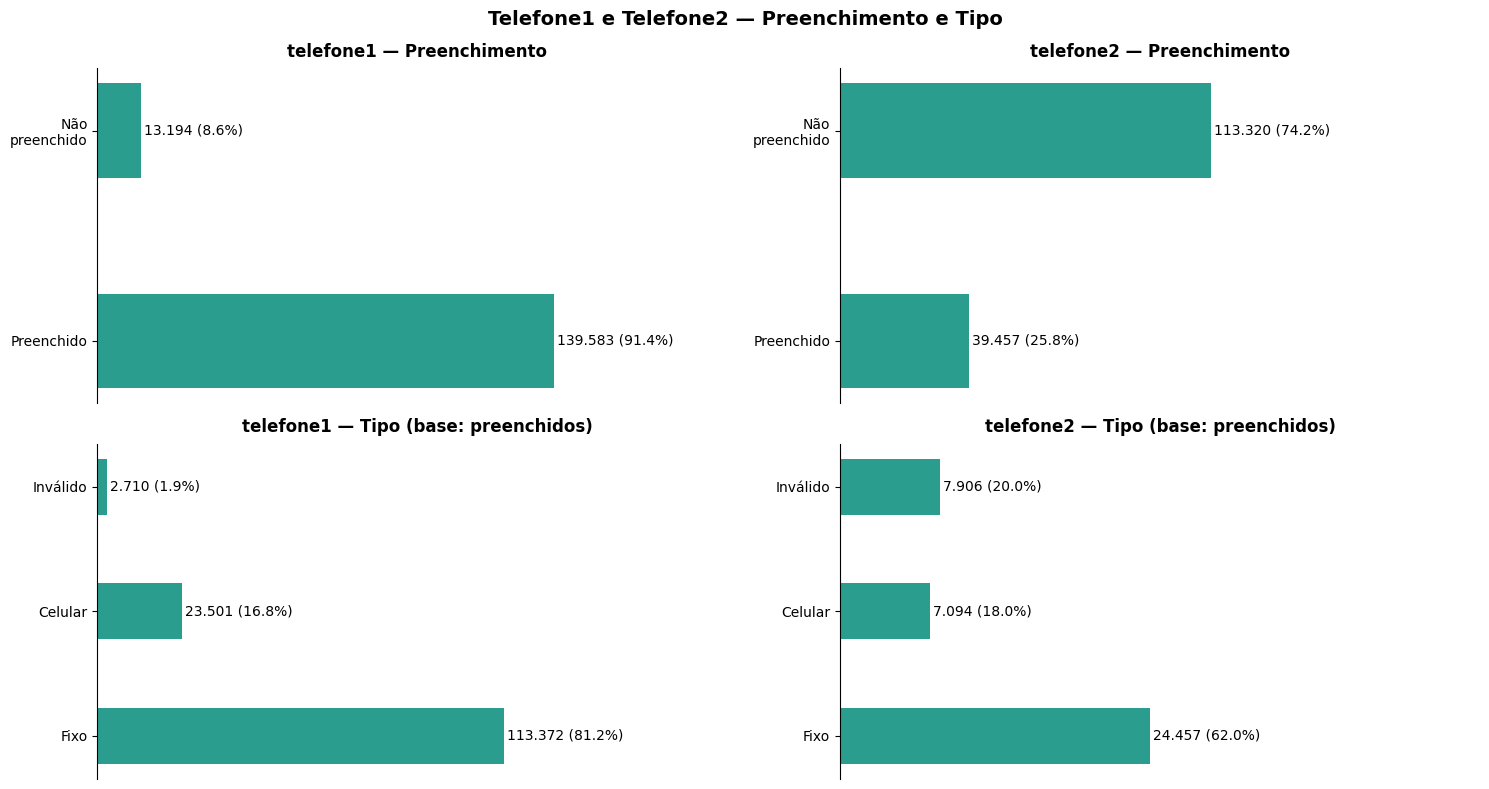

Preenchimento (base: total de estabelecimentos)


,Total empresas,Preenchido,Não preenchido
Campo,,,
telefone1,152.777 (100.0%),139.583 (91.4%),13.194 (8.6%)
telefone2,152.777 (100.0%),39.457 (25.8%),113.320 (74.2%)



Tipo de telefone (base: preenchidos)


,Total válidos,Fixo,Celular,Inválido
Campo,,,,
telefone1,136.873 (98.1%),113.372 (81.2%),23.501 (16.8%),2.710 (1.9%)
telefone2,31.551 (80.0%),24.457 (62.0%),7.094 (18.0%),7.906 (20.0%)


In [ ]:
import matplotlib.pyplot as plt

total_empresas = len(df)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Telefone1 e Telefone2 — Preenchimento e Tipo', fontsize=14, fontweight='bold')

COR = '#2a9d8f'

for col_idx, col_tel in enumerate(['telefone1', 'telefone2']):
    n_preenchido     = int(df[col_tel].notna().sum())
    n_nao_preenchido = total_empresas - n_preenchido
    pct_preench      = n_preenchido / total_empresas * 100
    pct_nao_preench  = 100 - pct_preench

    n_celular  = int(df[f'{col_tel}_celular'].sum())
    n_valido   = int(df[f'{col_tel}_valido'].sum())
    n_fixo     = n_valido - n_celular
    n_invalido = n_preenchido - n_valido

    # --- Grafico 1: preenchimento ---
    ax1 = axes[0, col_idx]
    rotulos1 = ['Preenchido', 'Nao\npreenchido']
    valores1 = [n_preenchido, n_nao_preenchido]
    pcts1    = [pct_preench, pct_nao_preench]
    bars1 = ax1.barh(rotulos1, valores1, color=COR, height=0.45)
    ax1.set_title(f'{col_tel} - Preenchimento', fontweight='bold', pad=8)
    for bar, n, pct in zip(bars1, valores1, pcts1):
        ax1.text(
            bar.get_width() + total_empresas * 0.006,
            bar.get_y() + bar.get_height() / 2,
            f'{n:,} ({pct:.1f}%)'.replace(',', '.'),
            va='center', fontsize=10,
        )
    ax1.set_xlim(0, total_empresas * 1.28)
    ax1.xaxis.set_visible(False)
    ax1.spines[['top', 'right', 'bottom']].set_visible(False)

    # --- Grafico 2: tipo (do total preenchido) ---
    ax2 = axes[1, col_idx]
    rotulos2 = ['Fixo', 'Celular', 'Invalido']
    valores2 = [n_fixo, n_celular, n_invalido]
    pcts2    = [v / n_preenchido * 100 for v in valores2]
    bars2 = ax2.barh(rotulos2, valores2, color=COR, height=0.45)
    ax2.set_title(f'{col_tel} - Tipo (base: preenchidos)', fontweight='bold', pad=8)
    for bar, n, pct in zip(bars2, valores2, pcts2):
        ax2.text(
            bar.get_width() + n_preenchido * 0.006,
            bar.get_y() + bar.get_height() / 2,
            f'{n:,} ({pct:.1f}%)'.replace(',', '.'),
            va='center', fontsize=10,
        )
    ax2.set_xlim(0, n_preenchido * 1.28)
    ax2.xaxis.set_visible(False)
    ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

def fmt(n, base):
    return f"{n:,} ({n/base*100:.1f}%)".replace(',', '.')

linhas_preench = []
linhas_tipo    = []

for col_tel in ['telefone1', 'telefone2']:
    n_preenchido     = int(df[col_tel].notna().sum())
    n_nao_preenchido = total_empresas - n_preenchido
    n_valido         = int(df[f'{col_tel}_valido'].sum())
    n_celular        = int(df[f'{col_tel}_celular'].sum())
    n_fixo           = n_valido - n_celular
    n_invalido       = n_preenchido - n_valido

    linhas_preench.append({
        'Campo'          : col_tel,
        'Total empresas' : fmt(total_empresas, total_empresas),
        'Preenchido'     : fmt(n_preenchido, total_empresas),
        'Nao preenchido' : fmt(n_nao_preenchido, total_empresas),
    })

    linhas_tipo.append({
        'Campo'             : col_tel,
        'Total preenchidos' : fmt(n_preenchido, total_empresas),
        'Fixo'              : fmt(n_fixo, n_preenchido),
        'Celular'           : fmt(n_celular, n_preenchido),
        'Invalido'          : fmt(n_invalido, n_preenchido),
    })

print('Preenchimento (base: total de estabelecimentos)')
display(pd.DataFrame(linhas_preench).set_index('Campo'))

print('\nTipo de telefone (base: preenchidos)')
display(pd.DataFrame(linhas_tipo).set_index('Campo'))